# Phase 1: Exploratory Data Analysis (EDA)
## Travel Destination Recommendation System

This notebook performs a comprehensive Exploratory Data Analysis (EDA) on the `tourism_recommendation_dataset_en.csv` dataset. The goals of this analysis are:
1. **Understand Dataset Structure**: Inspect dimensions, column data types, missing values, and duplicates.
2. **User Profile Exploration**: Investigate demographics (age, gender, origin province) and understand user diversity.
3. **Attraction Attribute Exploration**: Analyze classifications (categories, levels, cities, provinces, prices).
4. **Interaction History Exploration**: Inspect distribution of ratings, travel patterns, and expenditure.
5. **Sparsity & Connectivity**: Calculate User-Item matrix density and evaluate rating distributions.
6. **Modeling Strategy**: Document findings to establish clear preprocessing, feature engineering, and model training blueprints.


In [105]:
# Setup imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for academic/student assignment plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# File paths
DATA_PATH = "../data/tourism_recommendation_dataset_en.csv"


### 1. Data Loading and Basic Overview
First, we load the raw dataset and inspect its dimensions, columns, and sample records.


In [106]:
# Load dataset
df = pd.read_csv(DATA_PATH)
print(f"Dataset Shape: {df.shape}")
print(f"Number of rows (interactions): {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


Dataset Shape: (100000, 27)
Number of rows (interactions): 100000
Number of columns: 27


In [107]:
# View first 5 rows
df.head()


,tourist_id,gender,age,age_group,source_province,attraction_name,attraction_category,attraction_level,city,province,...,group_fee,trip_days,main_spots,transport_mode,season,is_holiday,recommendation_level,satisfaction_level,latitude,longitude
0,1,Female,67,56+,Beijing,Xuan Kong Si,Religious Culture,4A,Da Tong Shi,Shanxi,...,NaN,NaN,NaN,NaN,Winter,No,Recommend,Satisfied,NaN,NaN
1,2,Male,22,18-25,Heilongjiang,Kai Feng Fu,Historical Culture,4A,Kai Feng Shi,Henan,...,NaN,NaN,NaN,NaN,Autumn,No,Highly Recommend,Very Satisfied,34.685961,114.449220
2,3,Male,60,56+,Fujian,Zhou Zhuang Gu Zhen,Ancient Town,5A,Su Zhou Shi,Jiangsu,...,NaN,NaN,NaN,NaN,Summer,No,Recommend,Satisfied,31.115080,120.845944
3,4,Female,33,26-35,Ningxia,Zhu Jia Jiao Gu Zhen,Ancient Town,4A,Shanghai,Shanghai,...,NaN,NaN,NaN,NaN,Autumn,No,Recommend,Satisfied,31.113088,121.048879
4,5,Female,59,56+,Jiangxi,Lu Shan,Natural Culture,5A,Jiu Jiang Shi,Jiangxi,...,NaN,NaN,NaN,NaN,Winter,No,Highly Recommend,Very Satisfied,29.450592,116.039656


### 2. General Data Info, Missing Values, and Duplicates
Let's inspect data types, missing values, and check for duplicate rows.


In [108]:
# Check data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   tourist_id            100000 non-null  int64  
 1   gender                100000 non-null  str    
 2   age                   100000 non-null  int64  
 3   age_group             100000 non-null  str    
 4   source_province       100000 non-null  str    
 5   attraction_name       100000 non-null  str    
 6   attraction_category   100000 non-null  str    
 7   attraction_level      100000 non-null  str    
 8   city                  100000 non-null  str    
 9   province              100000 non-null  str    
 10  ticket_price          100000 non-null  int64  
 11  visit_date            100000 non-null  str    
 12  visit_duration_hours  100000 non-null  float64
 13  spend_amount          100000 non-null  float64
 14  other_spend           100000 non-null  float64
 15  rating      

In [109]:
# Calculate columns with missing values
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
print("Columns with missing values:")
print(missing_df)


Columns with missing values:
                Missing Count  Percentage (%)
group_fee               70242          70.242
trip_days               70242          70.242
main_spots              70242          70.242
transport_mode          70242          70.242
latitude                42094          42.094
longitude               42094          42.094


In [110]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows in the dataset: {duplicate_count}")


Number of duplicate rows in the dataset: 0


#### Discussion on Missing Values:
We see that `group_fee`, `trip_days`, `main_spots`, and `transport_mode` each have exactly **70,242** missing values (out of 100,000 rows). Let's verify if these missing values correspond exactly to records where the tour is not a group tour (`is_group_tour == 'No'`).


In [111]:
# Verify relation between is_group_tour and missing values
is_group_no = df[df['is_group_tour'] == 'No']
print(f"Number of interactions with is_group_tour == 'No': {len(is_group_no)}")
print("Null count in columns for non-group tours:")
print(is_group_no[['group_fee', 'trip_days', 'main_spots', 'transport_mode']].isnull().sum())


Number of interactions with is_group_tour == 'No': 70242
Null count in columns for non-group tours:
group_fee         70242
trip_days         70242
main_spots        70242
transport_mode    70242
dtype: int64


#### Implications of Missing Values:
1. **For Collaborative Filtering**: Collaborative filtering only relies on the ratings interaction matrix (User ID, Item ID, Rating). Demographics or tour metadata do not affect CF, so missing values have no impact.
2. **For Content-Based Filtering**: We can use attraction features such as category, level, city, province, and price. `main_spots` contains text which lists specific landmarks visited. Since it's missing for non-group tours, we can simply impute it with an empty string `""` or use `attraction_name` as a fallback.
3. **For Itinerary Planning**: `trip_days` in the interaction log represents the historical duration of that group tour. In our system, the itinerary module will build day-by-day itineraries based on *user input* in the Streamlit interface (e.g. how many days they want to travel). Thus, the historical `trip_days` in the dataset will not constrain our recommendations.


### 3. Data Consistency Check (Static Properties)
We need to verify if user demographics are static for each unique user, and if attraction attributes are static for each unique attraction name.


In [112]:
# Check if user attributes are static
unique_tourists = df['tourist_id'].nunique()
grouped_tourists = len(df.groupby(['tourist_id', 'gender', 'age', 'age_group', 'source_province']))
print(f"Unique tourist_ids: {unique_tourists}")
print(f"Unique combinations of tourist_id + demographics: {grouped_tourists}")
print(f"Are user demographics consistent? {unique_tourists == grouped_tourists}")


Unique tourist_ids: 10000
Unique combinations of tourist_id + demographics: 10000
Are user demographics consistent? True


In [113]:
# Check if attraction attributes are static
unique_attractions = df['attraction_name'].nunique()
grouped_attractions = len(df.groupby(['attraction_name', 'attraction_category', 'attraction_level', 'city', 'province', 'ticket_price']))
print(f"Unique attraction names: {unique_attractions}")
print(f"Unique combinations of attraction_name + static attributes: {grouped_attractions}")
print(f"Are attraction attributes consistent? {unique_attractions == grouped_attractions}")


Unique attraction names: 431
Unique combinations of attraction_name + static attributes: 433
Are attraction attributes consistent? False


#### Handling Duplicate Attraction Names
There are **431** unique attraction names, but **433** unique combinations of attraction characteristics. This implies some attraction names are shared by different physical attractions. Let's find them:


In [114]:
# Identify attraction names with varying attributes
grouped = df.groupby('attraction_name')[['attraction_category', 'attraction_level', 'city', 'province', 'ticket_price']].nunique()
varying_attractions = grouped[grouped.max(axis=1) > 1]
print("Attractions with varying static properties:")
print(varying_attractions)

# Display details for these duplicate attractions
for attr in varying_attractions.index:
    print(f"\nDetails for '{attr}':")
    print(df[df['attraction_name'] == attr][['attraction_name', 'attraction_category', 'attraction_level', 'city', 'province', 'ticket_price']].drop_duplicates())


Attractions with varying static properties:
                 attraction_category  attraction_level  city  province  \
attraction_name                                                          
Bai Yun Shan                       1                 1     2         2   
Hu Kou Pu Bu                       1                 1     2         2   

                 ticket_price  
attraction_name                
Bai Yun Shan                2  
Hu Kou Pu Bu                2  

Details for 'Bai Yun Shan':
    attraction_name attraction_category attraction_level            city  \
316    Bai Yun Shan     Natural Scenery               5A  Guang Zhou Shi   
695    Bai Yun Shan     Natural Scenery               5A    Luo Yang Shi   

      province  ticket_price  
316  Guangdong             5  
695      Henan            75  

Details for 'Hu Kou Pu Bu':
    attraction_name attraction_category attraction_level         city  \
307    Hu Kou Pu Bu     Natural Scenery               4A   Yan An Shi   
376  

#### Decision: Unique Attraction Identifier
There are two attraction names (`Bai Yun Shan` and `Hu Kou Pu Bu`) that exist in two different locations each:
- `Bai Yun Shan`: One is in Henan (Ticket Price: 75), the other is in Guangdong (Ticket Price: 5).
- `Hu Kou Pu Bu`: One is in Shanxi (Ticket Price: 100), the other is in Shaanxi (Ticket Price: 90).

To prevent recommending the wrong attraction or mixing up ratings:
1. In `src/preprocessing.py`, we **must create a unique attraction identifier** (e.g. combination of `attraction_name`, `city`, and `province`).
2. Let's verify that combining `attraction_name`, `city`, and `province` results in exactly 433 unique values.


In [115]:
# Confirm unique combination count
unique_keys = df.groupby(['attraction_name', 'city', 'province']).size().reset_index()
print(f"Number of unique attraction_name + city + province combinations: {len(unique_keys)}")


Number of unique attraction_name + city + province combinations: 433


### 4. Exploratory Analysis of User Demographics
Let's analyze user characteristics: `age`, `gender`, and `source_province`. We first construct a user-level dataframe since user demographics are static.


In [116]:
# Extract one row per tourist to get demographic distributions
user_df = df.groupby('tourist_id')[['gender', 'age', 'age_group', 'source_province']].first().reset_index()
print(f"Unique users: {len(user_df)}")
user_df.head()


Unique users: 10000


,tourist_id,gender,age,age_group,source_province
0,1,Female,67,56+,Beijing
1,2,Male,22,18-25,Heilongjiang
2,3,Male,60,56+,Fujian
3,4,Female,33,26-35,Ningxia
4,5,Female,59,56+,Jiangxi


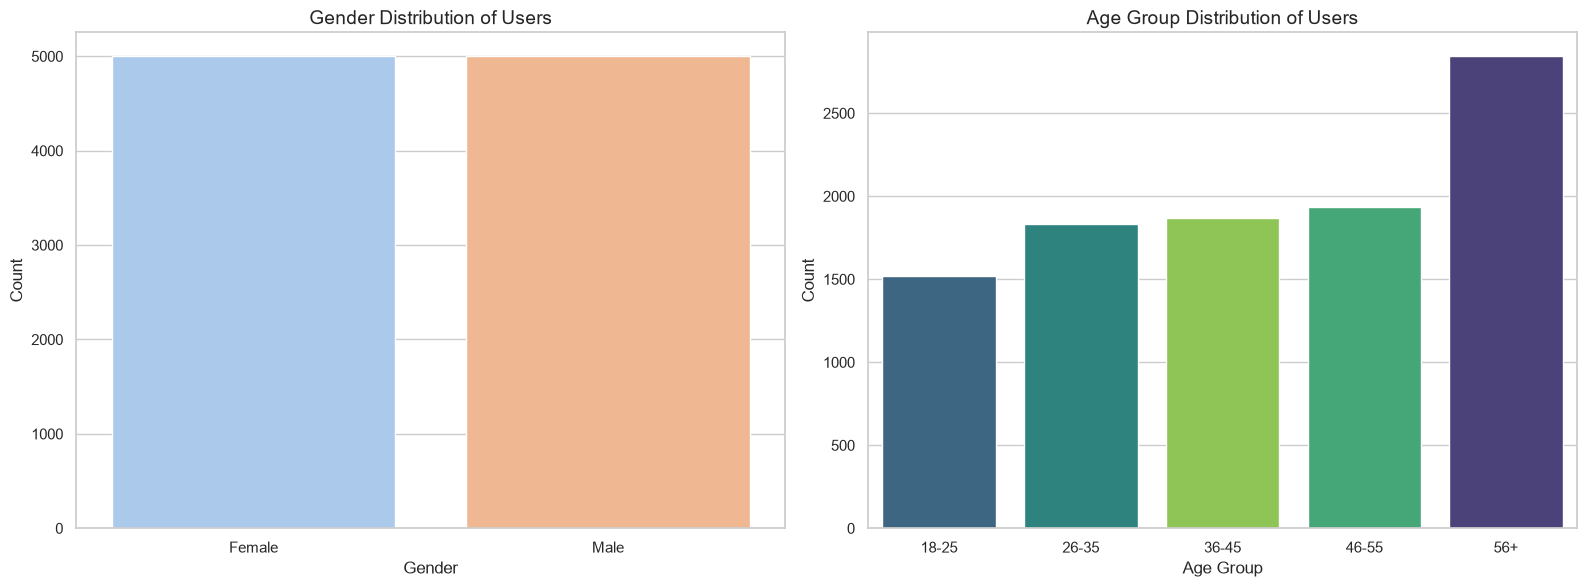

In [117]:
# Plot Gender and Age Group distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=user_df, x='gender', hue='gender', palette='pastel', ax=axes[0], legend=False)
axes[0].set_title('Gender Distribution of Users', fontsize=14)
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')

sns.countplot(data=user_df, x='age_group', hue='age_group', palette='viridis', order=sorted(user_df['age_group'].unique()), ax=axes[1], legend=False)
axes[1].set_title('Age Group Distribution of Users', fontsize=14)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


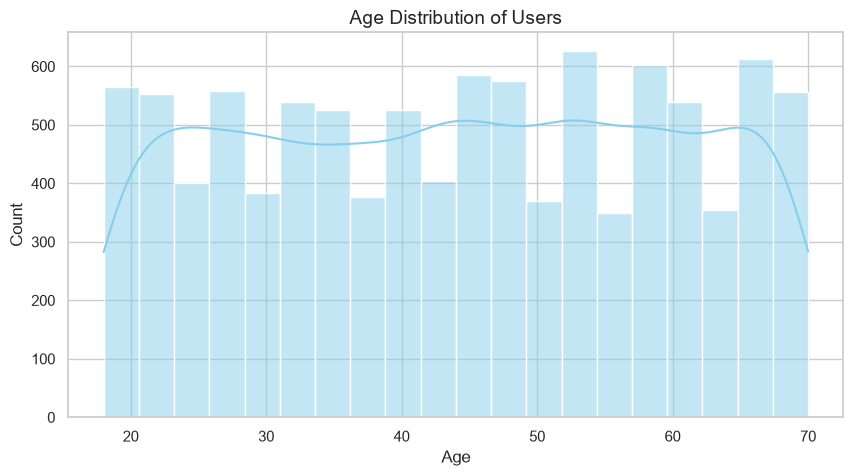

In [118]:
# Plot Age Distribution histogram
plt.figure(figsize=(10, 5))
sns.histplot(data=user_df, x='age', bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Users', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


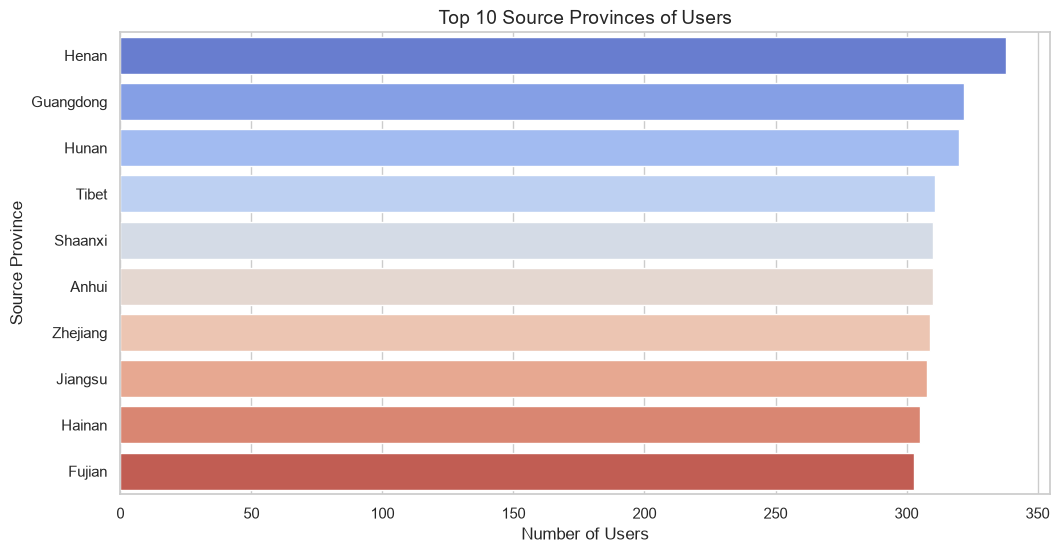

In [119]:
# Top 10 User Source Provinces
plt.figure(figsize=(12, 6))
top_provinces = user_df['source_province'].value_counts().head(10)
sns.barplot(x=top_provinces.values, y=top_provinces.index, hue=top_provinces.index, palette='coolwarm', legend=False)
plt.title('Top 10 Source Provinces of Users', fontsize=14)
plt.xlabel('Number of Users')
plt.ylabel('Source Province')
plt.show()


### 5. Exploratory Analysis of Attraction Attributes
Now, we explore the properties of the tourist attractions: `attraction_category`, `attraction_level`, and geographical distributions.


In [120]:
# Extract one row per unique physical attraction (433 unique locations)
attraction_df = df.groupby(['attraction_name', 'city', 'province']).first().reset_index()
print(f"Total Unique Attractions: {len(attraction_df)}")
attraction_df.head()


Total Unique Attractions: 433


,attraction_name,city,province,tourist_id,gender,age,age_group,source_province,attraction_category,attraction_level,...,group_fee,trip_days,main_spots,transport_mode,season,is_holiday,recommendation_level,satisfaction_level,latitude,longitude
0,798 Yi Shu Qu,Beijing,Beijing,569,Female,30,26-35,Xinjiang,Wen Hua Yi Shu,4A,...,2808.0,1.0,"Qing Xi Ling , Qing Cheng Shan , Long Yan Gu...",Gao Tie + Da Ba,Autumn,No,Recommend,Satisfied,39.875419,116.63045
1,An Qing Zhen Feng Ta,An Qing Shi,Anhui,264,Female,54,46-55,Guangdong,Historical Architecture,4A,...,6671.0,1.0,"Qing Dao Hai Bin Feng Jing Qu , Jian Shui Gu ...",Kong Tiao Da Ba,Chun Ji,No,Recommend,Satisfied,NaN,NaN
2,An Yuan Lu Kuang Gong Ren Yun Dong Ji Nian Guan,Ping Xiang Shi,Jiangxi,64,Male,27,26-35,Sichuan,Revolutionary Site,4A,...,2073.0,4.0,"Zi Que Jie Ti Tian , Qing Yuan Shan , Xiang ...",Kong Tiao Da Ba,Summer,No,Recommend,Satisfied,NaN,NaN
3,Ba Da Ling Chang Cheng,Beijing,Beijing,1061,Male,41,36-45,Taiwan,Historical Culture,5A,...,1973.0,5.0,"Mei Zhou Dao , Yan An Ge Ming Ji Nian Guan , ...",Gao Tie + Da Ba,Chun Ji,No,Recommend,Satisfied,NaN,NaN
4,Ba Li Gou,Xin Xiang Shi,Henan,321,Male,59,56+,Liaoning,Natural Scenery,4A,...,878.0,1.0,"Zha Long Zi Ran Bao Hu Qu , Pu Tuo Shan , Ti...",Gao Tie + Da Ba,Winter,Yes,Recommend,Satisfied,NaN,NaN


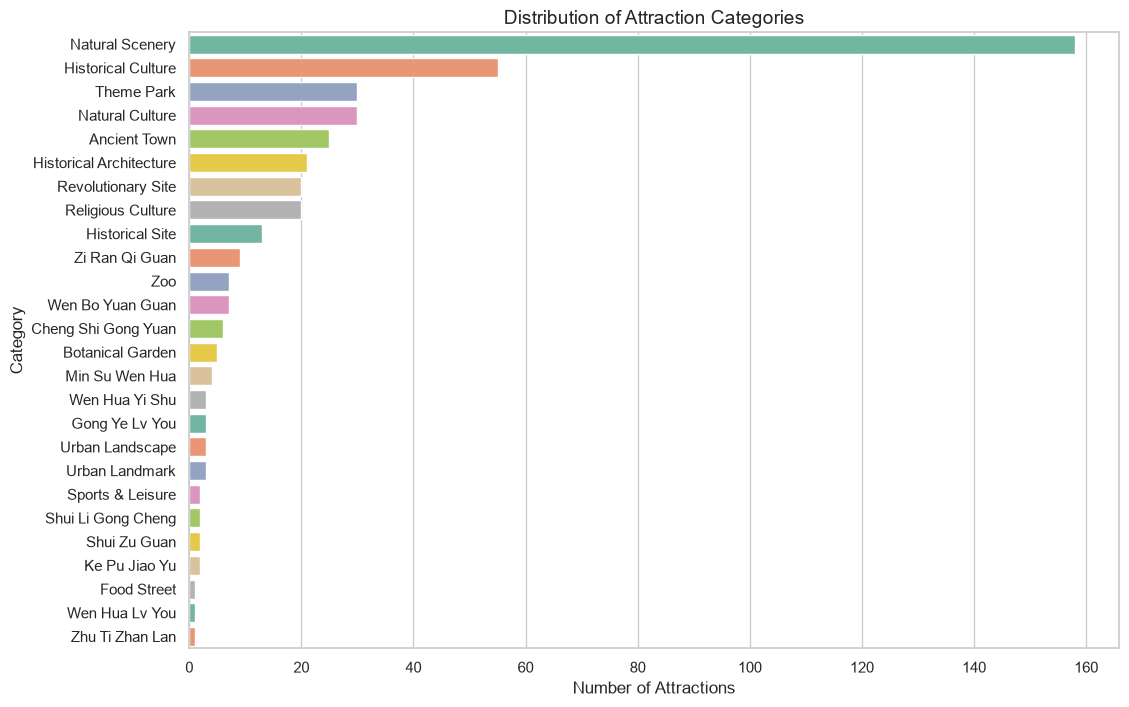

In [121]:
# Distribution of Attraction Categories
plt.figure(figsize=(12, 8))
cat_counts = attraction_df['attraction_category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, hue=cat_counts.index, palette='Set2', legend=False)
plt.title('Distribution of Attraction Categories', fontsize=14)
plt.xlabel('Number of Attractions')
plt.ylabel('Category')
plt.show()


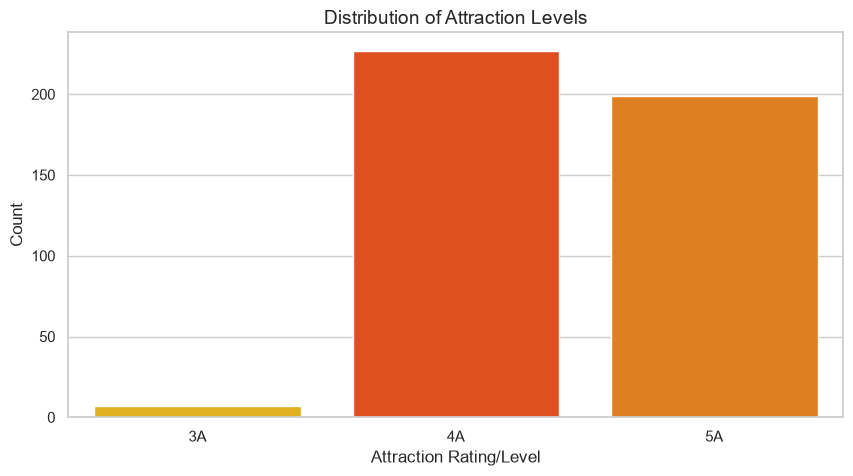

In [122]:
# Distribution of Attraction Levels
plt.figure(figsize=(10, 5))
level_order = sorted(attraction_df['attraction_level'].unique())
sns.countplot(data=attraction_df, x='attraction_level', hue='attraction_level', palette='autumn', order=level_order, ax=plt.gca(), legend=False)
plt.title('Distribution of Attraction Levels', fontsize=14)
plt.xlabel('Attraction Rating/Level')
plt.ylabel('Count')
plt.show()


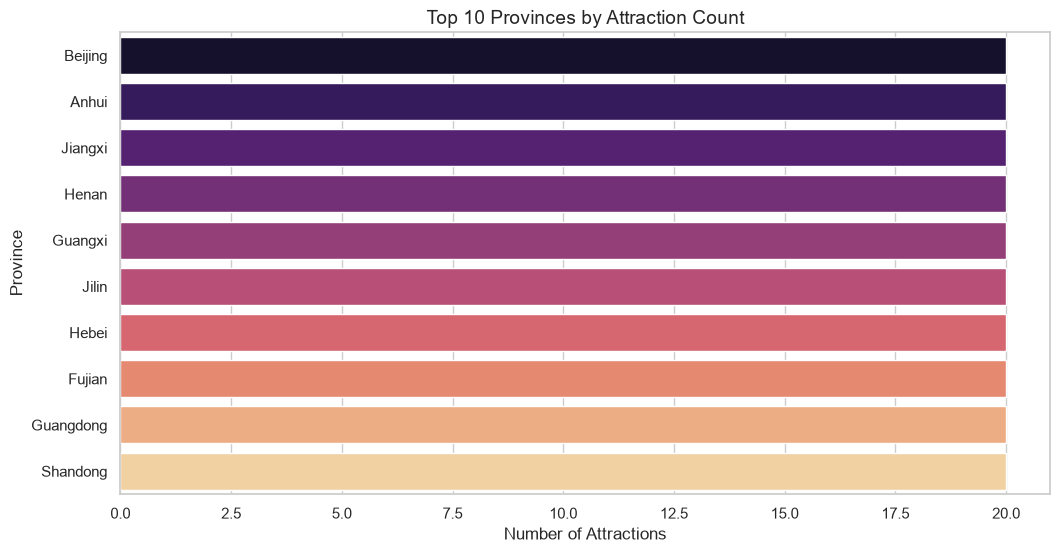

In [123]:
# Top 10 Provinces by Attraction Count
plt.figure(figsize=(12, 6))
top_attr_provinces = attraction_df['province'].value_counts().head(10)
sns.barplot(x=top_attr_provinces.values, y=top_attr_provinces.index, hue=top_attr_provinces.index, palette='magma', legend=False)
plt.title('Top 10 Provinces by Attraction Count', fontsize=14)
plt.xlabel('Number of Attractions')
plt.ylabel('Province')
plt.show()


### 6. Exploratory Analysis of Interaction Attributes
Let's analyze the properties of the user-attraction interactions, especially `rating`, `ticket_price`, and group tour status.


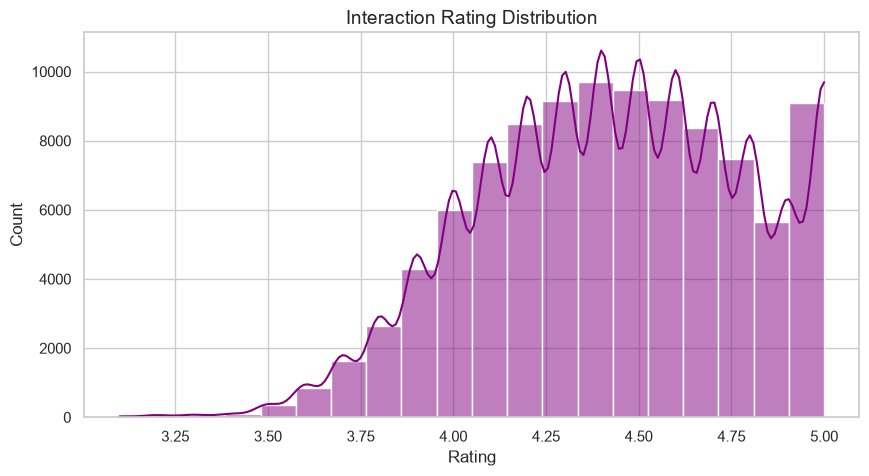

In [124]:
# Rating distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='rating', bins=20, kde=True, color='purple')
plt.title('Interaction Rating Distribution', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


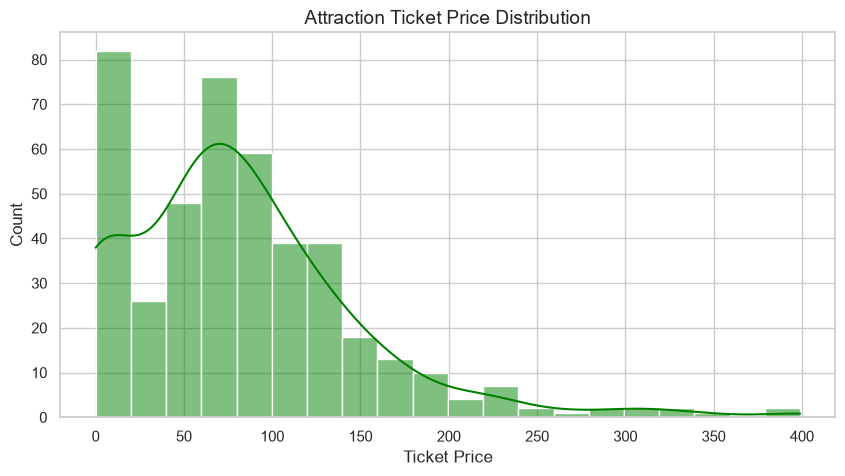

In [125]:
# Ticket Price distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=attraction_df, x='ticket_price', bins=20, kde=True, color='green')
plt.title('Attraction Ticket Price Distribution', fontsize=14)
plt.xlabel('Ticket Price')
plt.ylabel('Count')
plt.show()


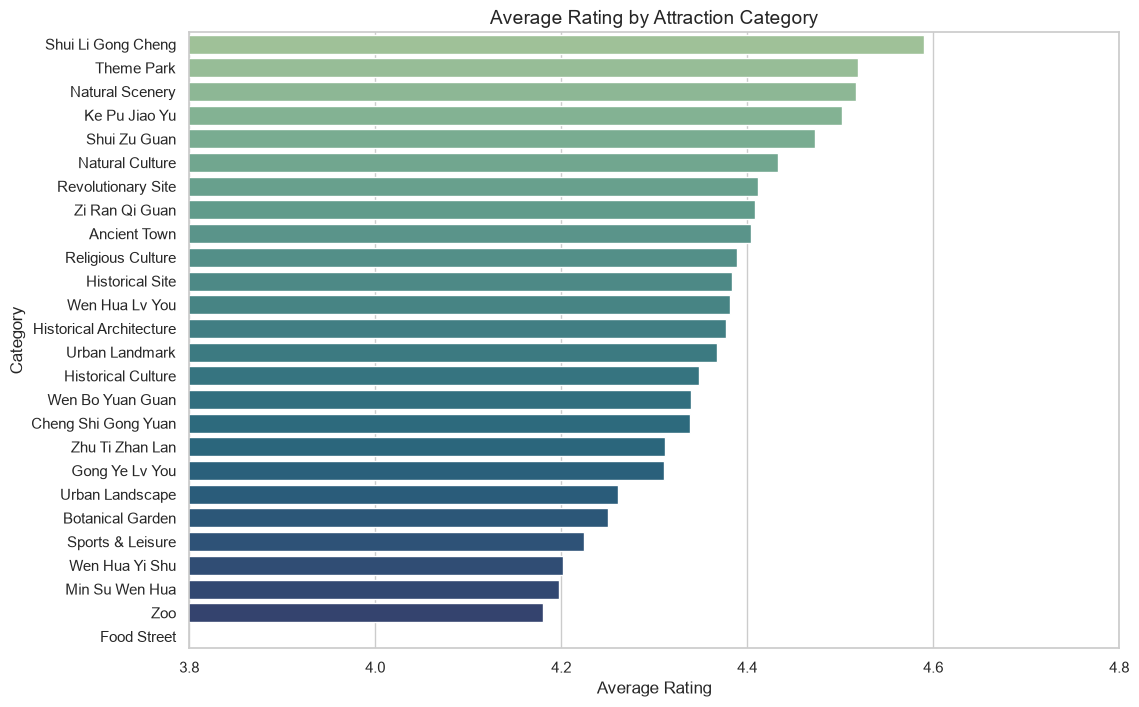

In [126]:
# Average Rating per Category
plt.figure(figsize=(12, 8))
avg_cat_rating = df.groupby('attraction_category')['rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_cat_rating.values, y=avg_cat_rating.index, hue=avg_cat_rating.index, palette='crest', legend=False)
plt.title('Average Rating by Attraction Category', fontsize=14)
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.xlim(3.8, 4.8) # Zoom in to see differences
plt.show()


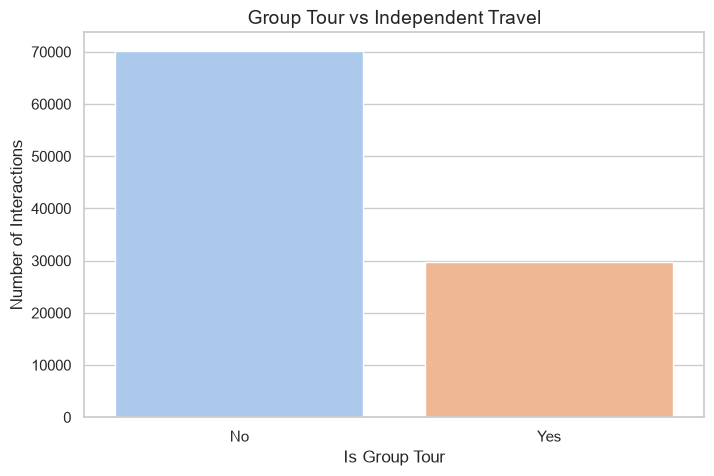

In [127]:
# Group tour vs Independent travel
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='is_group_tour', hue='is_group_tour', palette='pastel', legend=False)
plt.title('Group Tour vs Independent Travel', fontsize=14)
plt.xlabel('Is Group Tour')
plt.ylabel('Number of Interactions')
plt.show()


### 7. Interaction Density and Sparsity Analysis
For **Collaborative Filtering**, the density of the User-Item matrix determines prediction accuracy. Let's compute matrix dimensions and sparsity.


In [128]:
# Matrix Sparsity Calculation
num_users = df['tourist_id'].nunique()
num_items = len(df.groupby(['attraction_name', 'city', 'province'])) # 433 unique attractions
total_possible_interactions = num_users * num_items
actual_interactions = len(interactions)
sparsity = (1 - (actual_interactions / total_possible_interactions)) * 100

print(f"Number of Users (U): {num_users}")
print(f"Number of Items (I): {num_items}")
print(f"Total Possible Cell Values (U x I): {total_possible_interactions:,}")
print(f"Number of Actual Interactions: {actual_interactions:,}")
print(f"Sparsity: {sparsity:.4f}%")
print(f"Density: {100 - sparsity:.4f}%")


Number of Users (U): 10000
Number of Items (I): 433
Total Possible Cell Values (U x I): 4,330,000
Number of Actual Interactions: 98,869
Sparsity: 97.7167%
Density: 2.2833%


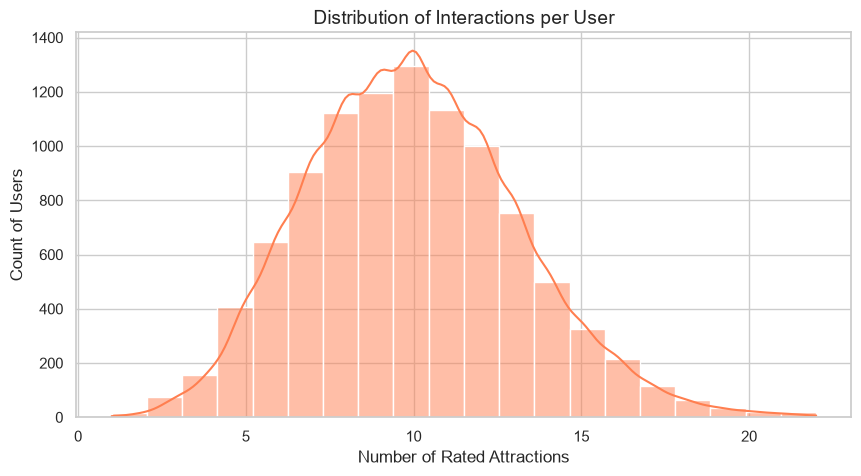

User Interactions Summary Stats:
count    10000.000000
mean        10.000000
std          3.124576
min          1.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         22.000000
dtype: float64


In [129]:
# Distribution of Interactions per User
user_interactions = df.groupby('tourist_id').size()
plt.figure(figsize=(10, 5))
sns.histplot(user_interactions, bins=20, kde=True, color='coral')
plt.title('Distribution of Interactions per User', fontsize=14)
plt.xlabel('Number of Rated Attractions')
plt.ylabel('Count of Users')
plt.show()

print("User Interactions Summary Stats:")
print(user_interactions.describe())


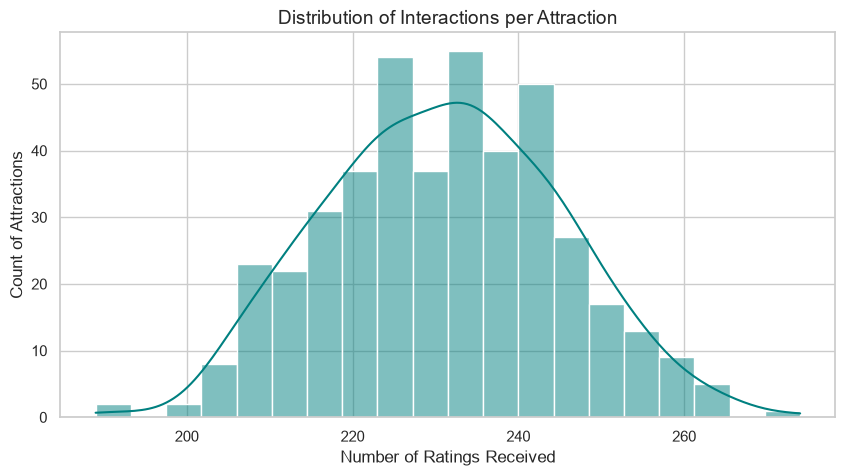

Attraction Interactions Summary Stats:
count    433.000000
mean     230.946882
std       14.109835
min      189.000000
25%      221.000000
50%      232.000000
75%      241.000000
max      274.000000
dtype: float64


In [130]:
# Distribution of Interactions per Attraction
attraction_interactions = df.groupby(['attraction_name', 'city', 'province']).size()
plt.figure(figsize=(10, 5))
sns.histplot(attraction_interactions, bins=20, kde=True, color='teal')
plt.title('Distribution of Interactions per Attraction', fontsize=14)
plt.xlabel('Number of Ratings Received')
plt.ylabel('Count of Attractions')
plt.show()

print("Attraction Interactions Summary Stats:")
print(attraction_interactions.describe())


### 8. Blueprint for Feature Engineering and Modeling
Based on our EDA, we formulate the following design decisions:

#### Preprocessing Layer (`src/preprocessing.py`)
1. **Unique Attraction Key**:
   Create a unique attraction key (e.g., column `attraction_id` or `attraction_uid`) by concatenating `attraction_name`, `city`, and `province`. This distinguishes the duplicate attractions (`Bai Yun Shan` and `Hu Kou Pu Bu`).
2. **Missing Value Imputation**:
   Fill the missing values of `main_spots` with an empty string `""` or `attraction_name`.
3. **Train-Test Split**:
   Implement a train-test split function (`train_test_split_by_user`) that splits the rating interactions of each user (e.g., reserving 20% of interactions per user for testing). This ensures we can measure precision, recall, and F1-score for all users.
4. **User-Item Matrix Representation**:
   Construct a pivot table where rows are `tourist_id`, columns are the unique attraction keys, and cells contain ratings. Unrated cells will be represented as `NaN` or `0`.

#### Content-Based Filtering (`src/content_based.py`)
1. **Attraction Feature Vector**:
   Represent each attraction as a text description or a vector of encoded categorical attributes. We will combine:
   - `attraction_category` (One-hot encoded)
   - `attraction_level` (Ordinal / One-hot encoded)
   - `province` (One-hot encoded)
   - `season` (One-hot encoded)
   - `ticket_price` (Min-max scaled or binned)
2. **TF-IDF representation**:
   Apply TF-IDF vectorization to convert `main_spots` (which lists sub-spots) or a concatenated textual representation of category/spots/city/province into numeric TF-IDF vectors.
3. **User Profile**:
   Build the user profile as a weighted average of the feature vectors of the attractions they have rated highly (e.g., rating $\ge 4.0$).
4. **Recommendation Generation**:
   Compute the cosine similarity between the user profile vector and all attraction feature vectors. Recommend the attractions with the highest similarity that the user has not yet visited.

#### Collaborative Filtering (`src/collaborative.py`)
1. **User Similarity**:
   Compute user-user cosine similarity based on the User-Item rating matrix. Since ratings are centered around 4.4, we can optionally subtract the user's mean rating (Pearson-like user-based CF) or use cosine similarity directly on the ratings.
2. **Prediction Formula**:
   Predict ratings for unvisited attractions as the weighted average of similarity-adjusted ratings of other users:
   $$\hat{R}_{u, i} = \bar{R}_u + \frac{\sum_{v \in S_u} \text{sim}(u, v) \cdot (R_{v, i} - \bar{R}_v)}{\sum_{v \in S_u} |\text{sim}(u, v)|}$$
3. **Cold Start**:
   If a user has fewer than 3 reviews, fall back to recommending the overall top-rated or most popular attractions within the preferred categories.


# Phase 2 — Preprocessing Analysis and Validation
## Travel Destination Recommendation System

This notebook performs validation, inspection, and verification of the dataset preprocessing stage.
It uses the existing preprocessing implementation in `src/preprocessing.py` to ensure raw data is transformed into clean attraction and interaction datasets ready for Content-Based Filtering (CBF) and User-Based Collaborative Filtering (UBCF) modeling.

### 1. Imports and Project Setup
We set up the matplotlib and seaborn plot styles, append the project directory to python's import path, and import the target functions from `src.preprocessing`.

In [131]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

# Add project root directory to sys.path to import src
PROJECT_DIR = Path.cwd().parent
sys.path.append(str(PROJECT_DIR))

from src.preprocessing import (
    load_dataset,
    validate_columns,
    clean_text,
    prepare_attractions,
    prepare_interactions,
    train_test_split_by_user
)

### 2. Load Raw Dataset
First, we load the raw dataset using `load_dataset()` and display its dimensions, column names, and sample records.

In [132]:
csv_path = PROJECT_DIR / "data" / "tourism_recommendation_dataset_en.csv"
print(f"Loading raw dataset from: {csv_path}")
raw_df = load_dataset(str(csv_path))

print(f"Dataset shape: {raw_df.shape}")
print(
    "Columns in raw dataset:",
    raw_df.columns.tolist()
)

print("\nFirst few rows:")
display(raw_df.head())

print("\nBasic Data Types:")
raw_df.info()

Loading raw dataset from: c:\Users\wuton\AndroidStudioProjects\travel-recommender\data\tourism_recommendation_dataset_en.csv
Dataset shape: (100000, 27)
Columns in raw dataset: ['tourist_id', 'gender', 'age', 'age_group', 'source_province', 'attraction_name', 'attraction_category', 'attraction_level', 'city', 'province', 'ticket_price', 'visit_date', 'visit_duration_hours', 'spend_amount', 'other_spend', 'rating', 'is_group_tour', 'group_fee', 'trip_days', 'main_spots', 'transport_mode', 'season', 'is_holiday', 'recommendation_level', 'satisfaction_level', 'latitude', 'longitude']

First few rows:


,tourist_id,gender,age,age_group,source_province,attraction_name,attraction_category,attraction_level,city,province,...,group_fee,trip_days,main_spots,transport_mode,season,is_holiday,recommendation_level,satisfaction_level,latitude,longitude
0,1,Female,67,56+,Beijing,Xuan Kong Si,Religious Culture,4A,Da Tong Shi,Shanxi,...,NaN,NaN,NaN,NaN,Winter,No,Recommend,Satisfied,NaN,NaN
1,2,Male,22,18-25,Heilongjiang,Kai Feng Fu,Historical Culture,4A,Kai Feng Shi,Henan,...,NaN,NaN,NaN,NaN,Autumn,No,Highly Recommend,Very Satisfied,34.685961,114.449220
2,3,Male,60,56+,Fujian,Zhou Zhuang Gu Zhen,Ancient Town,5A,Su Zhou Shi,Jiangsu,...,NaN,NaN,NaN,NaN,Summer,No,Recommend,Satisfied,31.115080,120.845944
3,4,Female,33,26-35,Ningxia,Zhu Jia Jiao Gu Zhen,Ancient Town,4A,Shanghai,Shanghai,...,NaN,NaN,NaN,NaN,Autumn,No,Recommend,Satisfied,31.113088,121.048879
4,5,Female,59,56+,Jiangxi,Lu Shan,Natural Culture,5A,Jiu Jiang Shi,Jiangxi,...,NaN,NaN,NaN,NaN,Winter,No,Highly Recommend,Very Satisfied,29.450592,116.039656



Basic Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   tourist_id            100000 non-null  int64  
 1   gender                100000 non-null  str    
 2   age                   100000 non-null  int64  
 3   age_group             100000 non-null  str    
 4   source_province       100000 non-null  str    
 5   attraction_name       100000 non-null  str    
 6   attraction_category   100000 non-null  str    
 7   attraction_level      100000 non-null  str    
 8   city                  100000 non-null  str    
 9   province              100000 non-null  str    
 10  ticket_price          100000 non-null  int64  
 11  visit_date            100000 non-null  str    
 12  visit_duration_hours  100000 non-null  float64
 13  spend_amount          100000 non-null  float64
 14  other_spend           100000 non-null  float6

### 3. Validate Required Columns
We validate that the loaded dataset contains all necessary columns. We also demonstrate that the column validation successfully catches invalid or missing fields.

In [133]:
required_columns = [
    "attraction_name",
    "attraction_category",
    "attraction_level",
    "city",
    "province",
    "ticket_price",
    "main_spots",
    "tourist_id",
    "rating"
]

print("Validating columns in raw dataset...")
validate_columns(raw_df, required_columns)
print("Validation succeeded!")

# Demonstrate validation failure for invalid columns
try:
    validate_columns(raw_df, ["non_existent_column"])
except ValueError as e:
    print(f"\nCaught expected column validation error:\n{e}")

Validating columns in raw dataset...
Validation succeeded!

Caught expected column validation error:
Missing required columns in dataset: non_existent_column


### 4. Text Cleaning Demonstration
We test the `clean_text()` function on sample string values to demonstrate how whitespace, punctuation, and uppercase characters are standardized.

In [134]:
print("Demonstrating text cleaning and normalization:")
test_cases = [
    "Shang Hai Ying Shi Le Yuan (Shanghai)",
    "A-level Attraction! Special spots & characters...",
    "   Beijing Palace Museum   ",
    np.nan,
    None
]
results = []
for case in test_cases:
    results.append({
        "Original": str(case),
        "Cleaned": clean_text(case)
    })
display(pd.DataFrame(results))

Demonstrating text cleaning and normalization:


,Original,Cleaned
0,Shang Hai Ying Shi Le Yuan (Shanghai),shang hai ying shi le yuan shanghai
1,A-level Attraction! Special spots & characters...,a level attraction special spots characters
2,Beijing Palace Museum,beijing palace museum
3,nan,
4,None,


### 5. Attraction Preprocessing
We prepare the clean unique attractions dataset by calling `prepare_attractions()`. We then check unique counts, verify the uniqueness of `attraction_uid`, check for missing values, and visualize attraction categories and cities distributions.

Preparing cleaned unique attractions dataset...
Prepared attractions shape: (433, 8)
Number of unique attraction_uids: 433
Uniqueness of attraction_uid: True

Missing values in prepared attractions:
attraction_uid         0
attraction_name        0
attraction_category    0
attraction_level       0
city                   0
province               0
ticket_price           0
main_spots_clean       0
dtype: int64

Sample records:


,attraction_uid,attraction_name,attraction_category,attraction_level,city,province,ticket_price,main_spots_clean
0,"Xuan Kong Si (Da Tong Shi, Shanxi)",Xuan Kong Si,Religious Culture,4A,Da Tong Shi,Shanxi,125,
1,"Kai Feng Fu (Kai Feng Shi, Henan)",Kai Feng Fu,Historical Culture,4A,Kai Feng Shi,Henan,65,
2,"Zhou Zhuang Gu Zhen (Su Zhou Shi, Jiangsu)",Zhou Zhuang Gu Zhen,Ancient Town,5A,Su Zhou Shi,Jiangsu,100,
3,"Zhu Jia Jiao Gu Zhen (Shanghai, Shanghai)",Zhu Jia Jiao Gu Zhen,Ancient Town,4A,Shanghai,Shanghai,60,
4,"Lu Shan (Jiu Jiang Shi, Jiangxi)",Lu Shan,Natural Culture,5A,Jiu Jiang Shi,Jiangxi,160,


C:\Users\wuton\AppData\Local\Temp\ipykernel_23296\1759943720.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\wuton\AppData\Local\Temp\ipykernel_23296\1759943720.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


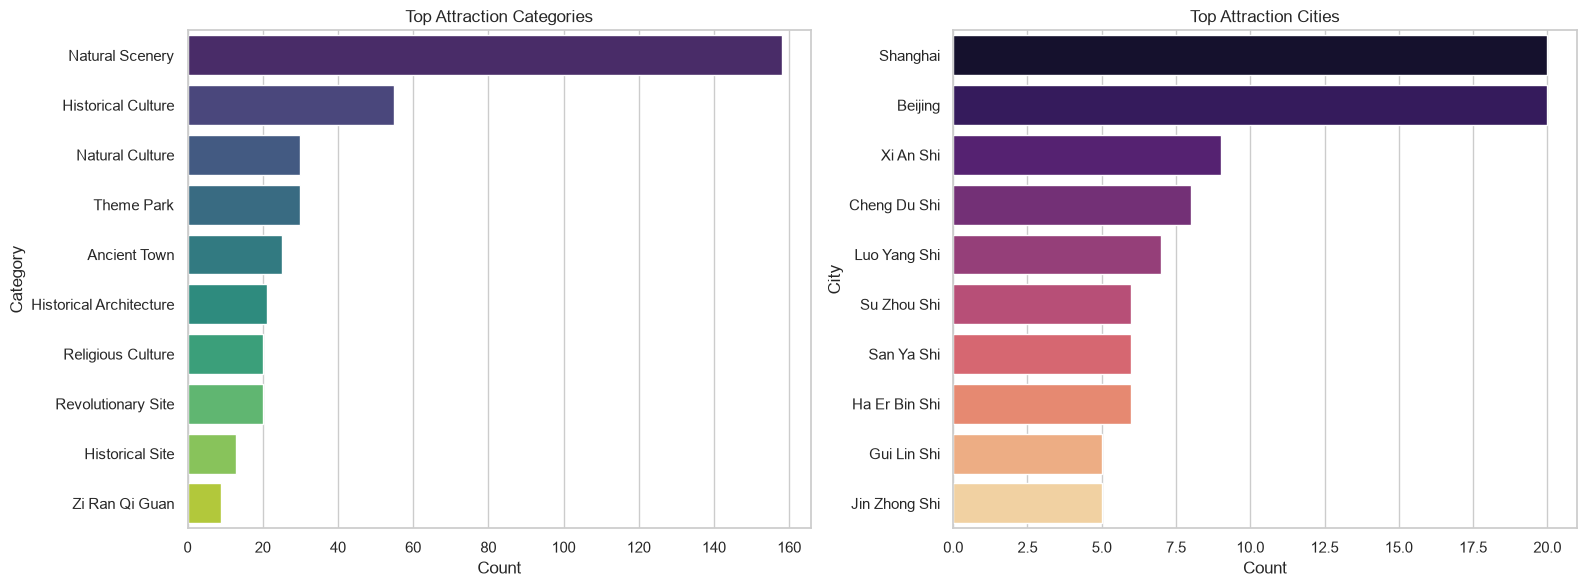

In [135]:
print("Preparing cleaned unique attractions dataset...")
attractions = prepare_attractions(raw_df)

print(f"Prepared attractions shape: {attractions.shape}")
print(f"Number of unique attraction_uids: {attractions['attraction_uid'].nunique()}")
print(f"Uniqueness of attraction_uid: {attractions['attraction_uid'].is_unique}")

print("\nMissing values in prepared attractions:")
print(attractions.isna().sum())

print("\nSample records:")
display(attractions.head())

# Visualizing top categories and cities
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(
    data=attractions,
    y="attraction_category",
    order=attractions["attraction_category"].value_counts().index[:10],
    ax=axes[0],
    palette="viridis"
)
axes[0].set_title("Top Attraction Categories")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Category")

sns.countplot(
    data=attractions,
    y="city",
    order=attractions["city"].value_counts().index[:10],
    ax=axes[1],
    palette="magma"
)
axes[1].set_title("Top Attraction Cities")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("City")

plt.tight_layout()
plt.show()

### 6. Interaction Preprocessing
We prepare the user-item interaction log by calling `prepare_interactions()`. We verify the user rating cardinallity, check for duplicate interactions, and visualize user ratings distributions.

Preparing interaction log dataset...
Prepared interactions shape: (98869, 3)
Number of unique tourists/users: 10000
Number of unique attractions: 433
Number of duplicate user-attraction pairs: 0

Missing values in prepared interactions:
tourist_id        0
attraction_uid    0
rating            0
dtype: int64

Sample records:


,tourist_id,attraction_uid,rating
0,1,"Bei Jing Zhi Wu Yuan (Beijing, Beijing)",4.0
1,1,"Du Fu Cao Tang (Cheng Du Shi, Sichuan)",3.9
2,1,"Gu Bei Shui Zhen (Beijing, Beijing)",4.9
3,1,"Ha Er Bin Bing Xue Da Shi Jie (Ha Er Bin Shi, ...",4.4
4,1,"Jing De Zhen Gu Yao (Jing De Zhen Shi, Jiangxi)",5.0


C:\Users\wuton\AppData\Local\Temp\ipykernel_23296\705148065.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=interactions, x="rating", palette="Blues_r")


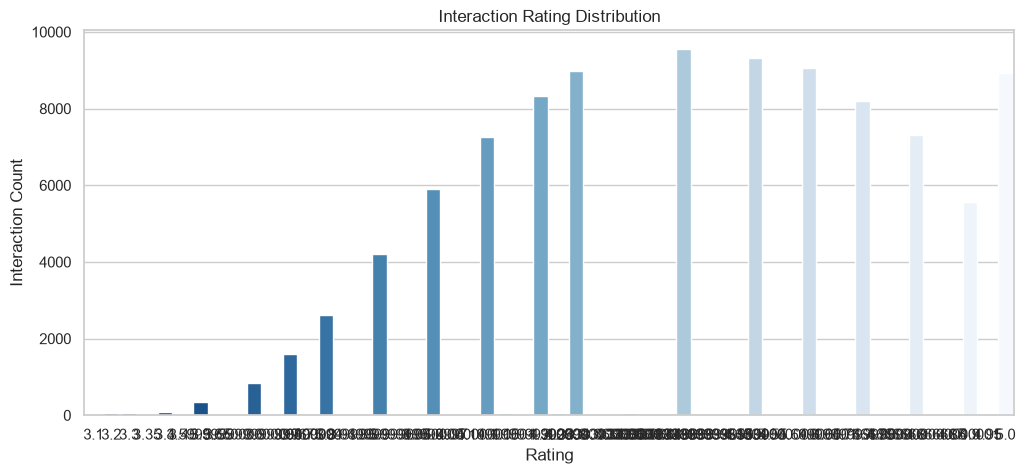

In [136]:
print("Preparing interaction log dataset...")
interactions = prepare_interactions(raw_df)

print(f"Prepared interactions shape: {interactions.shape}")
print(f"Number of unique tourists/users: {interactions['tourist_id'].nunique()}")
print(f"Number of unique attractions: {interactions['attraction_uid'].nunique()}")

duplicates_count = interactions.duplicated(subset=["tourist_id", "attraction_uid"]).sum()
print(f"Number of duplicate user-attraction pairs: {duplicates_count}")

print("\nMissing values in prepared interactions:")
print(interactions.isna().sum())

print("\nSample records:")
display(interactions.head())

# Rating distribution visualization
sns.countplot(data=interactions, x="rating", palette="Blues_r")
plt.title("Interaction Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Interaction Count")
plt.show()

### 7. Preprocessing Validation & Stratified Train/Test Split
We partition the prepared interaction log into per-user train/test sets using `train_test_split_by_user()`. We verify that all interaction records refer to a valid unique attraction ID in the prepared attractions table, checking relational consistency.

In [137]:
print("Performing stratified user interactions train/test split...")
train_df, test_df = train_test_split_by_user(
    interactions, 
    test_ratio=0.2, 
    min_interactions=5
)
print(f"Training interactions count: {len(train_df)}")
print(f"Testing interactions count: {len(test_df)}")

print("\nChecking relational consistency between prepared datasets:")
unmatched_uids = set(interactions["attraction_uid"]) - set(attractions["attraction_uid"])
print(f"Interactions referencing missing attraction records: {len(unmatched_uids)}")
assert len(unmatched_uids) == 0, "Error: Found interaction referencing a non-existent attraction!"

print("\nChecking train/test rating ranges:")
print(f"Training ratings: [{train_df['rating'].min()}, {train_df['rating'].max()}]")
print(f"Testing ratings: [{test_df['rating'].min()}, {test_df['rating'].max()}]")

print("\nVerifying train/test split consistency on sample user (tourist_id = 1):")
total_u = len(interactions[interactions["tourist_id"] == 1])
train_u = len(train_df[train_df["tourist_id"] == 1])
test_u = len(test_df[test_df["tourist_id"] == 1])
print(f"Tourist 1 - Total: {total_u}, Train: {train_u}, Test: {test_u} (Ratio: {test_u/total_u:.2%})")

Performing stratified user interactions train/test split...
Training interactions count: 79362
Testing interactions count: 19507

Checking relational consistency between prepared datasets:
Interactions referencing missing attraction records: 0

Checking train/test rating ranges:
Training ratings: [3.1, 5.0]
Testing ratings: [3.1, 5.0]

Verifying train/test split consistency on sample user (tourist_id = 1):
Tourist 1 - Total: 11, Train: 9, Test: 2 (Ratio: 18.18%)


### 8. Output Summary
We summarize the shape and cardinality of all prepared datasets ready for CBF and UBCF modeling.

In [138]:
# Constructing output summary table
summary_data = [
    {
        "Dataset": "Prepared Attractions",
        "Rows": len(attractions),
        "Columns": len(attractions.columns),
        "Users": "N/A",
        "Attractions": attractions["attraction_uid"].nunique()
    },
    {
        "Dataset": "Prepared Interactions (All)",
        "Rows": len(interactions),
        "Columns": len(interactions.columns),
        "Users": interactions["tourist_id"].nunique(),
        "Attractions": interactions["attraction_uid"].nunique()
    },
    {
        "Dataset": "Prepared Interactions (Train)",
        "Rows": len(train_df),
        "Columns": len(train_df.columns),
        "Users": train_df["tourist_id"].nunique(),
        "Attractions": train_df["attraction_uid"].nunique()
    },
    {
        "Dataset": "Prepared Interactions (Test)",
        "Rows": len(test_df),
        "Columns": len(test_df.columns),
        "Users": test_df["tourist_id"].nunique(),
        "Attractions": test_df["attraction_uid"].nunique()
    }
]
summary_table = pd.DataFrame(summary_data)
display(summary_table)

,Dataset,Rows,Columns,Users,Attractions
0,Prepared Attractions,433,8,N/A,433
1,Prepared Interactions (All),98869,3,10000,433
2,Prepared Interactions (Train),79362,3,10000,433
3,Prepared Interactions (Test),19507,3,9744,433
